## Electricity Usage Modelling

### Project Overview

This project aims to analyze the relationship between solar electricity generation and electricity consumption. It investigates whether electricity usage is influenced by solar production and examines how both variables vary across hours of the day and months of the year.

Based on the analysis, the study develops a statistical model to explain and predict electricity usage, providing insights into the patterns and factors affecting electricity demand.

### Methodology Overview
The dataset contains 4 variables and 8,760 observations, representing 24 hours of data for 365 days in the year 2020. The main objective of the study is to analyze the data to discover relationships between the variables and determine the most suitable statistical model to explain or predict electricity usage.

The project implements three polynomial regression models that experiment with different feature representations. The first model uses the data without any feature encoding, the second applies One-Hot encoding, and the third applies cyclical encoding for the categorical time-based features.

Polynomial regression was selected because, after extensive analysis, no clear linear relationship was observed between electricity usage and electricity generation or other engineered features. Therefore, polynomial regression was used to allow the model to capture potential non-linear relationships within the data.

### Data Exploration and Visualization 
Comprehensive data cleaning was conducted to prepare the dataset for modeling. An extreme outlier was identified in the electricity usage. This extreme outlier was replaced with the mean value to reduce its influence on the analysis and modelling.

A detailed data analysis was then performed to uncover patterns in electricity usage and solar electricity production. The findings were as follows:
    
-  Before adjusting the outlier, the **average electricity usage was 7.31 kWh**, while **solar-generated electricity was 1.12 kWh**. This indicated that the population consumed significantly more electricity than the solar system generated. After adjusting the outlier to the mean, **the average usage dropped to 2.06 kWh.**

- Five Negative electricity usage values were observed, which may indicate data collection errors or faulty systems. This requires further investigation since electricity usage would normally be expected to be positive.

- The **standard deviation of electricity usage was initially 491.47**, which was extremely large relative to the mean, suggesting the presence of extreme values or significant variability. After adjusting the outlier, the standard deviation **decreased significantly to 4.64**

- Solar electricity generation started increasing from **4:00 AM** until about **11:00 AM**, after which it began to decline gradually. This was unexpected because solar radiation is typically strongest in the afternoon, suggesting that electricity generation would normally peak later in the day. This observation may require further investigation.

- Electricity usage appeared to peak between **6:00 PM and 8:00 PM**, after which it started to decline. This pattern aligns with typical daily routines, where electricity consumption increases in the evening when people are active at home and decreases later at night when people go to sleep.

- No direct linear correlation was observed between electricity generation and electricity usage. Therefore, polynomial regression was applied to model electricity usage while incorporating time-based variables.

### Statistical modeling
Three polynomial regression models were constructed. The approaches for these models included:

    1. Training the model without any feature encoding
    2. Training the model with One-Hot encoding
    3. Training the model with Cyclical feature encoding

Each model was trained upto to the third polynomial degree and their performances were recorded for evaluation and comparision.

### Evaluation
The models were evaluated using a train–test split of the dataset. Since the data is time-based, the dataset was split chronologically. A random split was initially attempted; however, it was found to distort the underlying time patterns and resulted in poorer model performance.

Therefore, a chronological split was adopted, where the first 10 months of data were used to train the models, and the last 2 months were used for testing.

The metrics used to evaluate the performance of the three models were:

1. R<sup>2</sup> Score
2. RMSE(Root Mean Squared Error)

Overall, the three models did not perform as well as expected. The best-performing model was only able to explain approximately 11% of the variation in electricity usage, suggesting that the selected variables may not sufficiently capture the factors influencing electricity consumption. The model performance are listed below.

| Degree | R²       | RMSE     | Encoding |
|--------|----------|----------|----------------------|
| 1      | 0.115    | 4.77     | One-Hot              |
| 2      | 0.106    | 4.79     | Cyclical             | 
| 1      | 0.057    | 4.92     | None                 |

### Conclusion
- The study infers that electricity usage cannot be fully explained by time and electricity generation alone. Other factors likely influence electricity consumption, such as weather conditions, economic activity, and human behavior, as suggested by the time-based analysis.

- The study also concludes that solar electricity generation alone cannot sustain the energy demand of this particular population unless it is complemented by other sources of electricity. This is because electricity usage is about **1.85 times higher than the solar electricity generated.** Alternatively, the capacity of the current solar system would need to be expanded to meet the electricity demand.

#### 1. Module imports

- This imports all the libraries that will be used in this study.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
import warnings
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

#### 2. Data Imports

**Process:**
- Made a copy of the initial dataset
- Removed the first 2 rows, to remain with the variable names as the first row for use as headers.
- Then downloaded it as a CSV

In [2]:
df = pd.read_csv("Data for candidate 2026.csv")
df.head(2)

,Hour,Date/hour start,Solar electricity generation (kWh),Electricity usage (kWh)
0,0,1/1/20 0:00,0.0,1.5098490
1,1,1/1/20 1:00,0.0,1.4118588


In [3]:
df.shape

(8760, 4)

- The dataset has 8760 observations and 4 variables

#### 3. Data Cleaning

- Renaming the variables to remove the spacing

In [4]:
#fetching column names
columns = df.columns
columns

Index(['Hour', 'Date/hour start', 'Solar electricity generation (kWh)',
       'Electricity usage (kWh)'],
      dtype='object')

In [5]:
#renaming column names
df.rename(columns={"Date/hour start":"Date_hour","Solar electricity generation (kWh)":"Solar_generation_kwh","Electricity usage (kWh)":"Electricity_usage_kwh"}, inplace=True)
df.sample(2)

,Hour,Date_hour,Solar_generation_kwh,Electricity_usage_kwh
701,5,1/30/20 5:00,0.000,0.4560000
8315,11,12/13/20 11:00,0.423,2.4930000



- The **Date_hour** variable needs to be split. 
- Remove the hour column after spliting since such a variable a variable already exists.
- Convert that date column to a date column

In [6]:
#split the date/hour start column to new columns
df[["Date","Hour_2"]] = df["Date_hour"].str.split(' ', expand=True)
df.head(2)

,Hour,Date_hour,Solar_generation_kwh,Electricity_usage_kwh,Date,Hour_2
0,0,1/1/20 0:00,0.0,1.5098490,1/1/20,0:00
1,1,1/1/20 1:00,0.0,1.4118588,1/1/20,1:00


In [7]:
#dropping the splitted hour column
df = df.drop("Hour_2", axis=1)
df.sample(n=2, random_state=42)

,Hour,Date_hour,Solar_generation_kwh,Electricity_usage_kwh,Date
6056,8,9/10/20 8:00,2.253,6.0480000,9/10/20
5556,12,8/20/20 12:00,2.127,8.5410000,8/20/20


In [8]:
#checking for inconsistencies in the date column
df[["Month", "Day", "Year"]] = df["Date"].str.split("/", expand = True)
df.sample(2, random_state=42)

,Hour,Date_hour,Solar_generation_kwh,Electricity_usage_kwh,Date,Month,Day,Year
6056,8,9/10/20 8:00,2.253,6.0480000,9/10/20,9,10,20
5556,12,8/20/20 12:00,2.127,8.5410000,8/20/20,8,20,20


In [9]:
df.dtypes

Hour                       int64
Date_hour                 object
Solar_generation_kwh     float64
Electricity_usage_kwh     object
Date                      object
Month                     object
Day                       object
Year                      object
dtype: object

- The day, month and year columns are string objects. 
- Converting them to numbers to find the minimum and maximum in each column to determine which date format to use in the date.
- These splits will also act as engineered features later in the analysis and modeling 

In [10]:
#converting to numerical
df["Month"] = df["Month"].astype(int)
df["Day"] = df["Day"].astype(int)
df["Year"] = df["Year"].astype(int)

#These will also act as engineered features
#check max and min in each split column 
month_min = df["Month"].min()
month_max = df["Month"].max()

day_min = df["Day"].min()
day_max = df["Day"].max()

year_min = df["Year"].min()
year_max = df["Year"].max()

print("Month: ", "Minimum: ", month_min, ",", "Maximum: ", month_max)
print("Day: ", "Minimum: ", day_min, ",", "Maximum: ", day_max)
print("Year: ", "Minimum: ", year_min, ",", "Maximum: ", year_max)

Month:  Minimum:  1 , Maximum:  12
Day:  Minimum:  1 , Maximum:  31
Year:  Minimum:  20 , Maximum:  20


- The format of the date is month/day/year

In [11]:
#Convert date to datetime
warnings.filterwarnings('ignore') # ignoring the warnings
df["Date"] = pd.to_datetime(df['Date']) 
df.sample(n=2, random_state=42)


,Hour,Date_hour,Solar_generation_kwh,Electricity_usage_kwh,Date,Month,Day,Year
6056,8,9/10/20 8:00,2.253,6.0480000,2020-09-10,9,10,20
5556,12,8/20/20 12:00,2.127,8.5410000,2020-08-20,8,20,20


- Checking if the dataset has empty values

In [12]:
#Checking for nulls
null_values = df.isnull().sum()
null_values

Hour                     0
Date_hour                0
Solar_generation_kwh     0
Electricity_usage_kwh    0
Date                     0
Month                    0
Day                      0
Year                     0
dtype: int64

- There are no empty values
- Checking the datatypes of each variable/column

In [13]:
#checking datatypes
print(df.dtypes)

Hour                              int64
Date_hour                        object
Solar_generation_kwh            float64
Electricity_usage_kwh            object
Date                     datetime64[ns]
Month                             int32
Day                               int32
Year                              int32
dtype: object


- Electricity_usage_kwh usage has been saved as a string object. It can't be used like this for analysis and modeling. It has to be converted to numerical.

In [14]:
df["Electricity_usage_kwh"] = df["Electricity_usage_kwh"].astype(str).str.replace(",","", regex=True).astype(np.float64)
#some values had commas hence had to be romved for them to convert to float type
print(df.dtypes)

Hour                              int64
Date_hour                        object
Solar_generation_kwh            float64
Electricity_usage_kwh           float64
Date                     datetime64[ns]
Month                             int32
Day                               int32
Year                              int32
dtype: object


- Creating "day of the week" as an engineered feature for use in analysis and modeling

In [15]:
#adding day of week
#Engineered Feature
df["Day_of_week"] = df["Date"].dt.dayofweek

#### 4. Exploratory Data Analysis

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Hour                   8760 non-null   int64         
 1   Date_hour              8760 non-null   object        
 2   Solar_generation_kwh   8760 non-null   float64       
 3   Electricity_usage_kwh  8760 non-null   float64       
 4   Date                   8760 non-null   datetime64[ns]
 5   Month                  8760 non-null   int32         
 6   Day                    8760 non-null   int32         
 7   Year                   8760 non-null   int32         
 8   Day_of_week            8760 non-null   int32         
dtypes: datetime64[ns](1), float64(2), int32(4), int64(1), object(1)
memory usage: 479.2+ KB


**Observation**
- No missing values
- Data is in the correct datatype
- It's ready for analysis and statistical modeling 

In [17]:
df.describe()

,Hour,Solar_generation_kwh,Electricity_usage_kwh,Date,Month,Day,Year,Day_of_week
count,8760.000000,8760.000000,8760.000000,8760,8760.000000,8760.000000,8760.0,8760.000000
mean,11.500000,1.116750,7.312704,2020-07-01 20:07:13.972602880,6.526027,15.720548,20.0,2.991781
min,0.000000,0.000000,-12.624000,2020-01-01 00:00:00,1.000000,1.000000,20.0,0.000000
25%,5.750000,0.000000,0.300000,2020-04-02 00:00:00,4.000000,8.000000,20.0,1.000000
50%,11.500000,0.024000,0.621000,2020-07-02 00:00:00,7.000000,16.000000,20.0,3.000000
75%,17.250000,1.272750,1.686000,2020-10-01 00:00:00,10.000000,23.000000,20.0,5.000000
max,23.000000,13.050000,46000.000000,2020-12-31 00:00:00,12.000000,31.000000,20.0,6.000000
std,6.922582,2.026098,491.479806,NaN,3.448048,8.796749,0.0,1.995297


**Summary**
- Electricity generation starts from 0 to 13.05 kwh
- Electricity usage starts from -12.624 to 46000 kwh
- Average electricity usage is 7.313 while average electricity generated is 1.117, suggesting that this population is consuming way more electricity than what is being generated.
- 75% of the usage is below 1.686, this shows the max value of 46000 could be an outlier
- 75% of the generated electricity is below 1.273 while the maximum is 13.05, this could indicate there are outliers or some extremely high peaks
- The standard deviation in electricity usage is 491.47 suggesting a significance varaibility in electricity demand across the dataset.

**Checking for outliers**

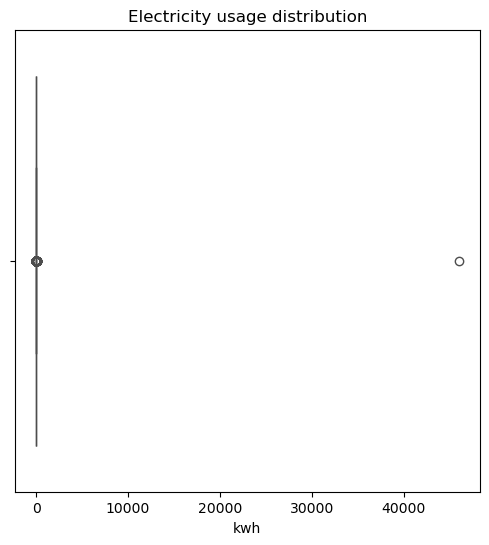

In [18]:
#plotting a box plot to check for outliers in the Electricity usage variable
fig, ax = plt.subplots(figsize=(6,6))
sns.boxplot(x=df["Electricity_usage_kwh"],vert=False, color="red")
plt.title("Electricity usage distribution")
plt.xlabel("kwh")
plt.show()

- The 46000 data point in Electricity usage is an outlier.
- This observation will be adjusted for modeling 

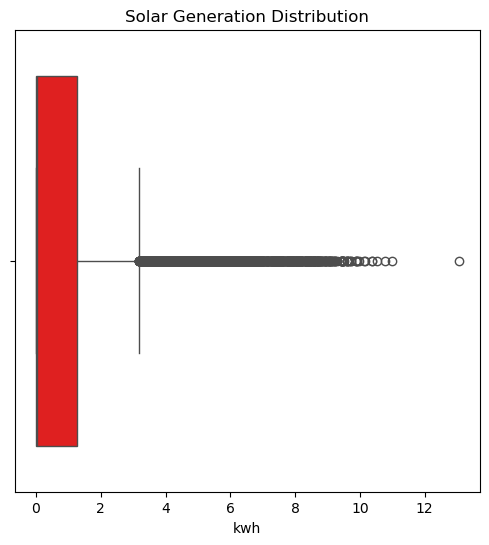

In [19]:
#plotting a boxplot to identify outliers in the Solar Generation variable
fig,ax = plt.subplots(figsize=(6,6))
sns.boxplot(x=df["Solar_generation_kwh"], vert=False, color="red")
plt.title("Solar Generation Distribution")
plt.xlabel("kwh")
plt.show()

- This confirms that the solar electricity generation has points above the upper quartile which suggest outliers or unusual peaks.
- These will not be dropped

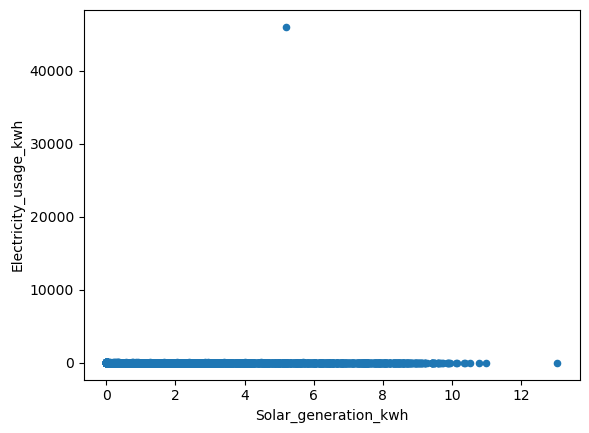

In [20]:
#scatter plot for the electricity production and the electricity usaage
df.plot(kind="scatter",x= "Solar_generation_kwh",y="Electricity_usage_kwh")
plt.show()

- This confirms that the (46000) data point is an error and an outlier that should be removed because it will distort the analysis and model
- Replacing that value with the mean

**Removing the outlier and doing descriptive statistics**

In [21]:
df_max= df["Electricity_usage_kwh"].max()
df.loc[df["Electricity_usage_kwh"] == df_max, "Electricity_usage_kwh"] = df["Electricity_usage_kwh"].mean()
df["Electricity_usage_kwh"].max()

61.1028

In [22]:
df.describe()

,Hour,Solar_generation_kwh,Electricity_usage_kwh,Date,Month,Day,Year,Day_of_week
count,8760.000000,8760.000000,8760.000000,8760,8760.000000,8760.000000,8760.0,8760.000000
mean,11.500000,1.116750,2.062397,2020-07-01 20:07:13.972602880,6.526027,15.720548,20.0,2.991781
min,0.000000,0.000000,-12.624000,2020-01-01 00:00:00,1.000000,1.000000,20.0,0.000000
25%,5.750000,0.000000,0.300000,2020-04-02 00:00:00,4.000000,8.000000,20.0,1.000000
50%,11.500000,0.024000,0.621000,2020-07-02 00:00:00,7.000000,16.000000,20.0,3.000000
75%,17.250000,1.272750,1.686000,2020-10-01 00:00:00,10.000000,23.000000,20.0,5.000000
max,23.000000,13.050000,61.102800,2020-12-31 00:00:00,12.000000,31.000000,20.0,6.000000
std,6.922582,2.026098,4.641624,NaN,3.448048,8.796749,0.0,1.995297


- With the oultier adjusted to mean, the average usage is 1.8 times the average production

#### Visual cards for the Summary

In [23]:
display(HTML("""<h3> Statistical Summary</h3>"""))

#Electricity production
ave_prod = df["Solar_generation_kwh"].mean()
min_prod = df["Solar_generation_kwh"].min()
max_prod = df["Solar_generation_kwh"].max()

measures = [ave_prod, min_prod, max_prod]
titles = ["Average Production","Minimum Production","Maximum Production"]
colors = ["blue","purple","green"]
cards_html = "" #Storing all cards
for idx, measure in enumerate(measures):
    
    cards_html += f"""
    <div style="display:inline-block;border:1px solid;  width:250px; min-height:150px; border-radius:10px; background-color:{colors[idx]}; color:white;text-align:center;">
    <h4> {titles[idx]}</h4>
    <p style = text-align:center;>{measures[idx]:.2f} kwh</p>
    </div>
    """
display(HTML(cards_html)) 

#Electricity usage 
ave_usage = df["Electricity_usage_kwh"].mean()
min_usage = df["Electricity_usage_kwh"].min()
max_usage = df["Electricity_usage_kwh"].max()

measures = [ave_usage, min_usage, max_usage]
titles = ["Average Consumption","Minimum Consumption","Maximum Consumption"]
colors = ["indigo","violet","Orange"]
cards_html = "" #Storing all cards to show display them horizontally
for idx, measure in enumerate(measures):
    
    cards_html += f"""
    <div style="display:inline-block;border:1px solid;  width:250px; min-height:150px; border-radius:10px; background-color:{colors[idx]}; color:white;text-align:center;">
    <h4> {titles[idx]}</h4>
    <p style = text-align:center;>{measures[idx]:.2f} kwh</p>
    </div>
    """
display(HTML(cards_html)) 

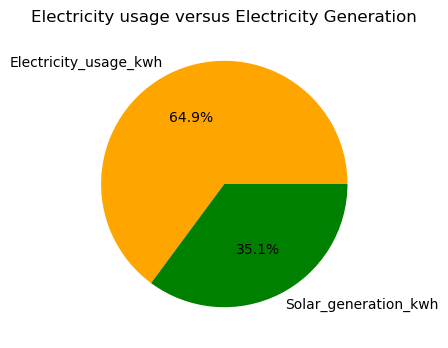

In [24]:
#plot electricity usage versus electricity generation
fig, ax = plt.subplots(figsize=(4,4))
colors = ["orange","green"]
df[["Electricity_usage_kwh","Solar_generation_kwh"]].mean().plot(kind='pie',autopct='%1.1f%%',colors=colors)
plt.title("Electricity usage versus Electricity Generation")
plt.show()

**Usage versus generation interpretation**
- The electricity consumption is 1.8 times higher the production
- The minimum consumption being negative shows that there are some observations where consumption is negative.
- More analysis is required on these negatives to understand what is happening

In [25]:
#counting observations that are less than 0
negatives = (df["Electricity_usage_kwh"]< 0).sum()
print("No. of observations with negative electricity usage: ", negatives)

No. of observations with negative electricity usage:  5


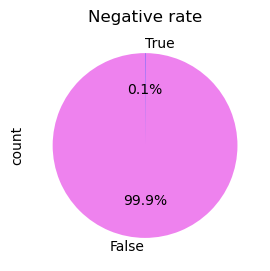

In [26]:
fig,ax = plt.subplots(figsize=(3,3))
colors = ["violet","blue"]
(df["Electricity_usage_kwh"]< 0).value_counts().plot(kind="pie", autopct='%1.1f%%',ax=ax, startangle=90,colors=colors)
plt.title("Negative rate")
plt.show()

In [27]:
df[df["Electricity_usage_kwh"]< 0]

,Hour,Date_hour,Solar_generation_kwh,Electricity_usage_kwh,Date,Month,Day,Year,Day_of_week
17,17,1/1/20 17:00,0.006,-12.6240,2020-01-01,1,1,20,2
933,21,2/8/20 21:00,0.006,-2.1330,2020-02-08,2,8,20,5
935,23,2/8/20 23:00,0.000,-0.2175,2020-02-08,2,8,20,5
3593,17,5/30/20 17:00,1.185,-2.5140,2020-05-30,5,30,20,5
6464,8,9/27/20 8:00,0.717,-1.9770,2020-09-27,9,27,20,6


**Negative values Explanation**
- There are 5 cases of negative electricity usage, representing approximately 0.1% of the dataset.
- These values are likely due to data collection errors or faulty measurement systems and should be investigated further, as electricity usage is normally expected to be positive.

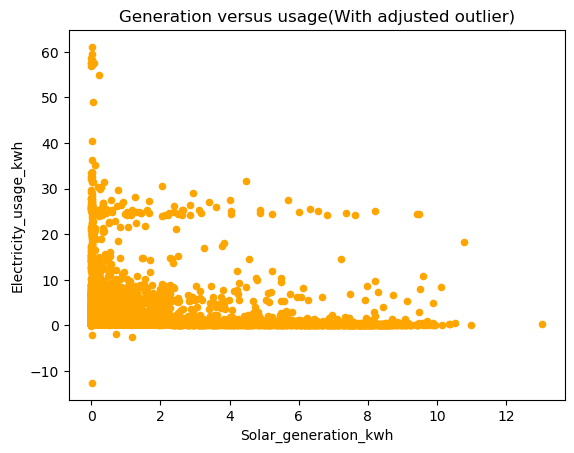

In [28]:
df.plot(kind='scatter', x="Solar_generation_kwh", y="Electricity_usage_kwh", color="orange")
plt.title("Generation versus usage(With adjusted outlier)")
plt.show()

**Relationship between electricity genarated and electricity used Analysis**
- Most points are clustered around 0 to 2.5kwh electricity generated and 0-10kwh electricity used
- There is no present linear relationship showing that power generated does not affect electricity usage 
- There is also no obvious causal relationship observed
- This suggests that other factors may be contributing to electricity generation and electricity usage

                       Solar_generation_kwh  Electricity_usage_kwh
Solar_generation_kwh               1.000000              -0.077467
Electricity_usage_kwh             -0.077467               1.000000


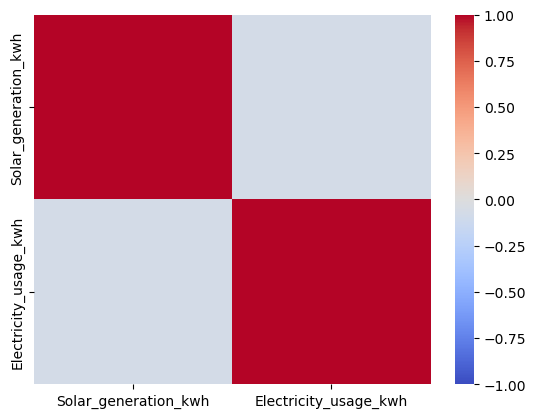

In [29]:
correlation_matrix = df[["Solar_generation_kwh","Electricity_usage_kwh"]].corr()
print(correlation_matrix)
sns.heatmap(correlation_matrix, vmax=1, vmin=-1, cmap='coolwarm')
plt.show()

- Heatmap confirms that there is no correlation between the production and usage of electricity

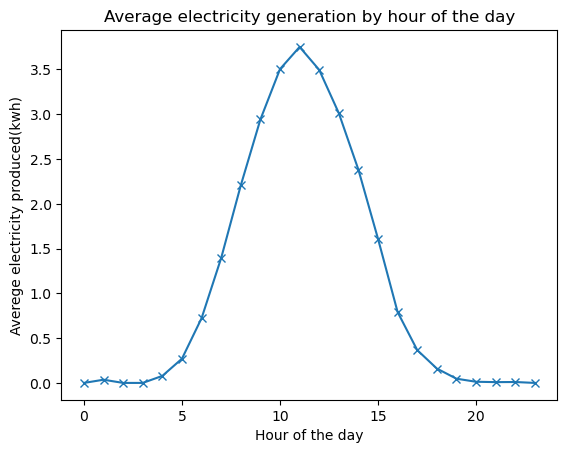

In [30]:
#Hour of the day analysis for production
df.groupby("Hour")["Solar_generation_kwh"].mean().plot(kind="line", marker='x')
plt.title("Average electricity generation by hour of the day")
plt.ylabel("Averege electricity produced(kwh)")
plt.xlabel("Hour of the day")
plt.show()

**Hour of the day analysis**
- Electricity genaration starts from 4am and stops at 7pm
- Electricity generation is usually at it highest peak at the 11am
- During the day, electricity is generated the most.

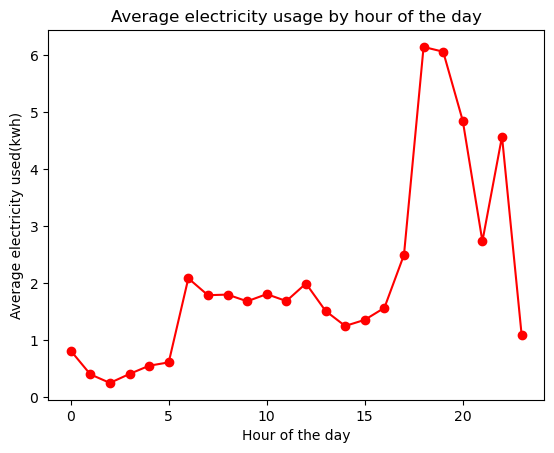

In [31]:
#Hour of the day analysis for production
df.groupby("Hour")["Electricity_usage_kwh"].mean().plot(kind="line", color="red", marker='o')
plt.title("Average electricity usage by hour of the day")
plt.ylabel("Average electricity used(kwh)")
plt.xlabel("Hour of the day")
plt.show()

**Electricity usage by hour interpretation**
- Electricity usage is highest from 6pm to 20pm, drops at 9pm then peaks a bit at 10pm
- Electricity usage is lowest from 11pm to 5pm
- This pattern mimicks human routine

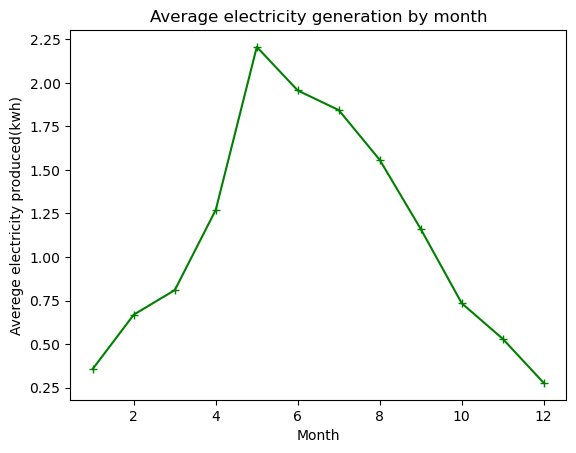

In [32]:
#Monthly analysis for production
df.groupby("Month")["Solar_generation_kwh"].mean().plot(kind="line", marker='+', color='green')
plt.title("Average electricity generation by month")
plt.ylabel("Averege electricity produced(kwh)")
plt.xlabel("Month")
plt.show()

**Monthly production Analysis**

- Electricity generation is at its highest peak in May
- Its lowest in January and December
- This pattern could mimick seasons depending on the geographical location the data was collected

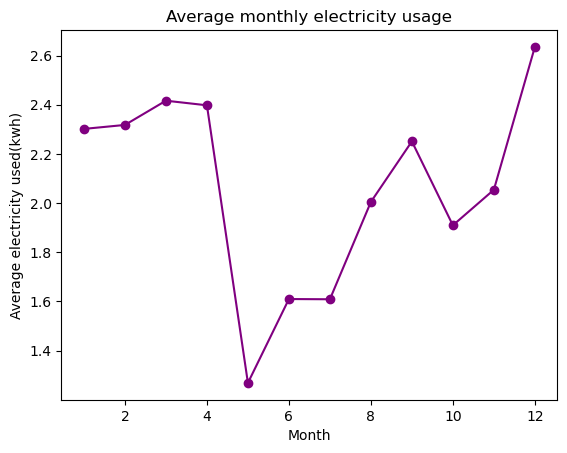

In [33]:
#Monthly analysis for usage
df.groupby("Month")["Electricity_usage_kwh"].mean().plot(kind="line", color="purple", marker='o')
plt.title("Average monthly electricity usage")
plt.ylabel("Average electricity used(kwh)")
plt.xlabel("Month")
plt.show()

**Monthly electricity usage analysis**
- Electricity consumption is highest in December
- Electricity consumption is lowest in May
- This is **contrary** because **electricity generation** is **highest in May** but **lowest in December**

**Analysis by Day of the week**

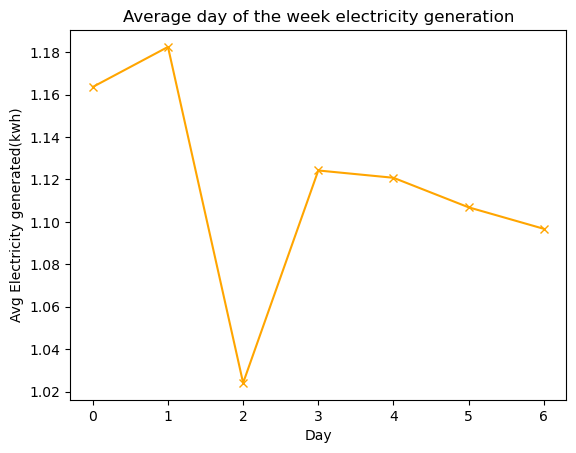

In [34]:
#Day of week analysis for generation
df.groupby("Day_of_week")["Solar_generation_kwh"].mean().plot(kind="line", color="orange", marker='x')
plt.title("Average day of the week electricity generation")
plt.ylabel("Avg Electricity generated(kwh)")
plt.xlabel("Day")
plt.show()

**Generation by days of week observation**
- Electricity is high on Tuesdays and Lowest on Wednesdays

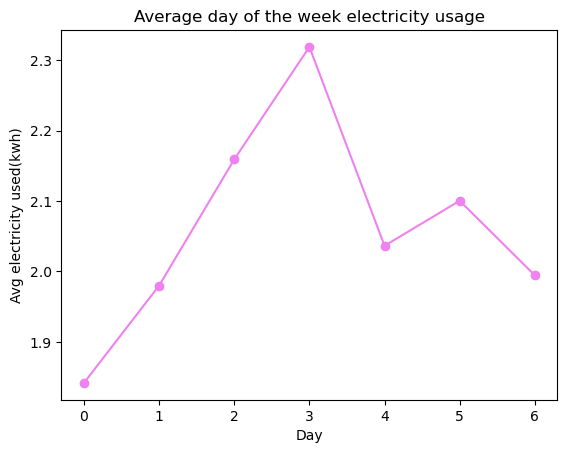

In [35]:
#Day of week analysis for usage
df.groupby("Day_of_week")["Electricity_usage_kwh"].mean().plot(kind="line", color="violet", marker='o')
plt.title("Average day of the week electricity usage")
plt.ylabel("Avg electricity used(kwh)")
plt.xlabel("Day")
plt.show()

**Electricity usage by days of the week observation**
- Usage increases gradually from Monday to Thursday the drops from Thursday to Saturday

#### 5. Statistical Modeling and Evaluation

- The relationships observed were non-linear
- Polynomial regression will be used to predict usage
- All the 4 variables i.e Hour, Month, Day_of_week and Solar_generation_kwh will be used
- The data will be split chronologically; first 10 months for training and 3 months for testing

#### Model 1: No Feature encoding

In [36]:
X = df[["Hour","Month","Solar_generation_kwh","Day_of_week"]]
y = df[['Electricity_usage_kwh',"Month"]]

#Spliting for training and testing
X_train = X[X['Month'] <= 9]
X_test = X[X['Month'] > 9]
y_train = y[y['Month'] <= 9]
y_test = y[y['Month'] >9]

#drop_month before training
y_train = y_train.drop("Month", axis=1)
y_test = y_test.drop("Month", axis=1)

degrees_original= []
r2_original = []
rmse_original = []

In [37]:
#using degree 1 - 3 for 
for degree in range(1,4): 
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    poly_X_train = poly.fit_transform(X_train)
    poly_X_test = poly.transform(X_test)
    
    #Building a linear regression model using the polynomial features to predict electricity usage
    model = LinearRegression()
    model.fit(poly_X_train,y_train)

    #Making predictions
    y_pred = model.predict(poly_X_test)

    
    
    #Evaluating performance
    r2 = r2_score(y_test, y_pred)
    print("degree", degree ,"R2: ",r2)
    mse = mean_squared_error(y_test,y_pred)
    print("degree", degree , "rmse: ", np.sqrt(mse))
    #storing for ploting and model comparison
    degrees_original.append(degree)
    r2_original.append(r2)
    rmse_original.append(np.sqrt(mse))

degree 1 R2:  0.0572927820437793
degree 1 rmse:  4.92311950235536
degree 2 R2:  0.05141574023412998
degree 2 rmse:  4.938441558012134
degree 3 R2:  -0.2567500590090508
degree 3 rmse:  5.684292516264204


**Evaluation**
- For a range of 3 degrees in polynomial features the model performance is decreasing.
- The best output is obtained polynomial degree of 1

#### Model 2: One Hot feature encoding
- One hot encoding the categorical variables to check whether the performance of the model will improve
- The categorical variables to be encoded are hour, month and day_of_week

In [38]:
X = df[["Hour","Month","Solar_generation_kwh","Day_of_week"]]
y = df[['Electricity_usage_kwh',"Month"]]

#Spliting for training and testing
X_train = X[X['Month'] <= 9]
X_test = X[X['Month'] > 9]
y_train = y[y['Month'] <= 9]
y_test = y[y['Month'] >9]

#drop_month before training
y_train = y_train.drop("Month", axis=1)
y_test = y_test.drop("Month", axis=1)

#Encoding
X_train = pd.get_dummies(X_train,columns=["Hour","Month","Day_of_week"],drop_first=True)
X_test = pd.get_dummies(X_test,columns=["Hour","Month","Day_of_week"],drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

degrees_encod= []
r2_encod = []
rmse_encod = []

In [39]:
#Building model 2
for degree in range(1,4): 
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    poly_X_train = poly.fit_transform(X_train)
    poly_X_test = poly.transform(X_test)
    
    #Building a linear regression model using the polynomial features to predict electricity usage
    model = LinearRegression()
    model.fit(poly_X_train,y_train)

    #Making predictions
    y_pred = model.predict(poly_X_test)

    #Evaluating performance
    r2 = r2_score(y_test, y_pred)
    print("degree", degree ,"R2: ",r2)
    mse = mean_squared_error(y_test,y_pred)
    print("degree", degree , "rmse: ", np.sqrt(mse))
    
    #storing for ploting and model comparison
    degrees_encod.append(degree)
    r2_encod.append(r2)
    rmse_encod.append(np.sqrt(mse))
    

degree 1 R2:  0.115441455421601
degree 1 rmse:  4.76886746354564
degree 2 R2:  0.06664790603510762
degree 2 rmse:  4.898630867284465
degree 3 R2:  -0.7968031644712978
degree 3 rmse:  6.796764362020017


- The best output is obtained at polynomial degree of 1
- Performance decreases as degrees increase

#### Model 3: Cyclical Feature Encoding

In [40]:
#Cyclical encoding for the categorical features to show they are close to each other
cols_with_categorical = ["Hour", "Month","Day_of_week"]
for col in cols_with_categorical:
    if col == "Month":
        df[col+"_sin"] = np.sin(2 * np.pi * df[col]/12)
        df[col + "_cos"] = np.cos( 2 * np.pi * df[col]/12)
    elif col == "Hour":
        df[col+"_sin"] = np.sin(2 * np.pi * df[col]/24)
        df[col + "_cos"] = np.cos( 2 * np.pi * df[col]/24)
    else:
        df[col+"_sin"] = np.sin(2 * np.pi * df[col]/7)
        df[col + "_cos"] = np.cos( 2 * np.pi * df[col]/7)

print(df.columns)

Index(['Hour', 'Date_hour', 'Solar_generation_kwh', 'Electricity_usage_kwh',
       'Date', 'Month', 'Day', 'Year', 'Day_of_week', 'Hour_sin', 'Hour_cos',
       'Month_sin', 'Month_cos', 'Day_of_week_sin', 'Day_of_week_cos'],
      dtype='object')


In [41]:
#splitting data for train and test chronologically

df_train = df[df["Month"] <= 9]
df_test = df[df["Month"] > 9]
X_train = df_train.drop(["Hour","Date_hour","Electricity_usage_kwh","Date","Month","Day","Year","Day_of_week"],axis=1)
y_train = df_train["Electricity_usage_kwh"]
X_test = df_test.drop(["Hour","Date_hour","Electricity_usage_kwh","Date","Month","Day","Year","Day_of_week"],axis=1)
y_test = df_test["Electricity_usage_kwh"]

degrees_cyclic = []
r2_cyclic = []
rmse_cyclic = []

In [42]:
#Building model 3
for degree in range(1,4): 
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    poly_X_train = poly.fit_transform(X_train)
    poly_X_test = poly.transform(X_test)
    
    #Building a linear regression model using the polynomial features to predict electricity usage
    model = LinearRegression()
    model.fit(poly_X_train,y_train)

    #Making predictions
    y_pred = model.predict(poly_X_test)

    #Evaluating performance
    r2 = r2_score(y_test, y_pred)
    print("degree", degree ,"R2: ",r2)
    mse = mean_squared_error(y_test,y_pred)
    print("degree", degree , "rmse: ", np.sqrt(mse))
    
    #storing for ploting and model comparison
    degrees_cyclic.append(degree)
    r2_cyclic.append(r2)
    rmse_cyclic.append(np.sqrt(mse))
    

degree 1 R2:  0.05453589552726834
degree 1 rmse:  4.930312919907408
degree 2 R2:  0.10635727684048302
degree 2 rmse:  4.793292408074677
degree 3 R2:  0.02616992647403993
degree 3 rmse:  5.003726376777055


- Unlike other models, the best output is obtained at polynomial degree of 2

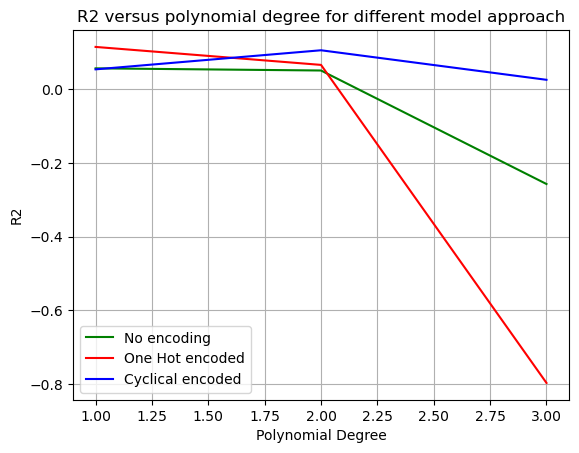

In [43]:
plt.plot(degrees_original,r2_original, color="green", label="No encoding")
plt.plot(degrees_encod, r2_encod, color="red", label="One Hot encoded")
plt.plot(degrees_cyclic, r2_cyclic, color="blue", label="Cyclical encoded")
plt.title("R2 versus polynomial degree for different model approach")
plt.xlabel("Polynomial Degree")
plt.ylabel("R2")
plt.legend()
plt.grid(True)
plt.show()

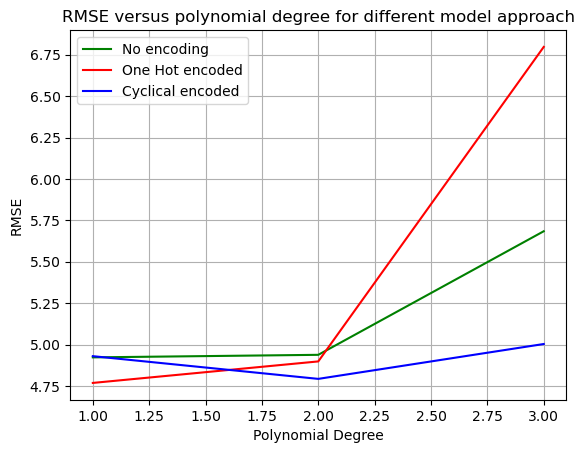

In [44]:
plt.plot(degrees_original,rmse_original, color="green", label="No encoding")
plt.plot(degrees_encod, rmse_encod, color="red", label="One Hot encoded")
plt.plot(degrees_cyclic, rmse_cyclic, color="blue", label="Cyclical encoded")
plt.title("RMSE versus polynomial degree for different model approach")
plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

- Overall, the three models performed poorly. The One-Hot encoded model performed the best, achieving an **R² score of 0.115** and an **RMSE of 4.77 kWh.**
  
- This model is able to explain only **11% of the variability** in electricity usage, with a **prediction error of 4.77 kWh**.
  
| Degree | R²       | RMSE     | Encoding |
|--------|----------|----------|----------------------|
| 1      | 0.115    | 4.77     | One-Hot              |
| 2      | 0.106    | 4.79     | Cyclical             | 
| 1      | 0.057    | 4.92     | None                 |

#### 6. Conclusion

- Electricity usage cannot be explained by generation alone; it is heavily influenced by human activity, as seen in factors such as time, day of the week, and season. However, these factors by themselves also do not fully explain usage, since the best-performing model was only able to explain 11% of the variation in electricity consumption.

- Electricity generation starts increasing gradually in the morning and then drops gradually from the late morning hours. This drop is unexpected, as solar production would normally continue increasing until around 2 PM, when it is usually hottest. These data warrant further investigation to understand the cause of the drop or whether it reflects an issue in the electricity generation system.

- This particular population is consuming electricity at approximately 1.85 times the rate of solar generation, meaning that solar power alone cannot sustain their demand. They would require additional sources of electricity to meet consumption. Alternatively, meeting the full demand through solar energy alone would require an expansion of the solar generation capacity, potentially increasing the number of solar panels two times.